# Segmentation clients RFM — Online Retail II

**TAISS 2026 · Filière F1 (Data Science) · TP2**
Équipe : *[noms]* — Lomé, août 2026

Parties 1 à 4 : nettoyage, features RFM, clustering, caractérisation.

## 0. Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             adjusted_rand_score)

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
sns.set_theme(style="whitegrid")

# Graine fixée : sans elle, K-means donnerait un résultat différent à chaque
# exécution et les chiffres du rapport ne seraient pas reproductibles.
GRAINE = 42

RAW  = Path("../data/raw/online_retail_II.xlsx")
PROC = Path("../data/processed"); PROC.mkdir(parents=True, exist_ok=True)
FIG  = Path("../figures");        FIG.mkdir(parents=True, exist_ok=True)

---
# Partie 1 — Nettoyage des transactions

## 1.1 Chargement

In [2]:
# Le fichier contient deux feuilles annuelles à concaténer.
# La colonne Source garde la trace de la feuille d'origine : elle sert au
# contrôle pour checker le chevauchement
xl = pd.ExcelFile(RAW)

frames = []
for feuille in xl.sheet_names:
    d = xl.parse(feuille)
    d["Source"] = feuille
    frames.append(d)

df = pd.concat(frames, ignore_index=True).rename(columns={"Customer ID": "CustomerID"})
N_BRUT = len(df)

print(f"{N_BRUT:,} lignes brutes | {df.CustomerID.nunique()} clients | "
      f"{df.InvoiceDate.min():%d/%m/%Y} → {df.InvoiceDate.max():%d/%m/%Y}")
df.head(3)

1,067,371 lignes brutes | 5942 clients | 01/12/2009 → 09/12/2011


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,Source
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom,Year 2009-2010
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom,Year 2009-2010
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom,Year 2009-2010


In [3]:
print(df.isna().sum())

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
CustomerID     243007
Country             0
Source              0
dtype: int64


## 1.2 Journal de nettoyage

In [4]:
# Chaque filtre est enregistré (nom, lignes restantes, lignes retirées).
# Ce journal est exporté en CSV : il rend le nettoyage vérifiable et rejouable.
journal = []

def etape(nom, d, commentaire=""):
    precedent = journal[-1]["restant"] if journal else N_BRUT
    journal.append({"etape": nom, "restant": len(d),
                    "retirees": precedent - len(d), "commentaire": commentaire})
    print(f"{nom:34s} -{precedent - len(d):>8,}  →  {len(d):>9,}")
    return d

## 1.3 Doublons exacts

In [37]:

COLS_METIER = ["Invoice", "StockCode", "Description", "Quantity",
               "InvoiceDate", "Price", "CustomerID", "Country"]

f1, f2 = xl.sheet_names
for f in (f1, f2):
    d = df[df.Source == f]
    print(f"{f}: {d.InvoiceDate.min():%d/%m/%Y} → {d.InvoiceDate.max():%d/%m/%Y}")

communes = set(df.loc[df.Source == f1, "Invoice"]) & set(df.loc[df.Source == f2, "Invoice"])
total  = df.duplicated(subset=COLS_METIER).sum()
intra  = (df[df.Source == f1].duplicated(subset=COLS_METIER).sum()
          + df[df.Source == f2].duplicated(subset=COLS_METIER).sum())

print(f"\nFactures présentes dans les deux feuilles : {len(communes):,}")
print(f"Doublons intra-feuille : {intra:,} | dus au chevauchement : {total - intra:,}")

df = etape("doublons exacts", df.drop_duplicates(subset=COLS_METIER),
           "export + chevauchement des 2 feuilles")

Year 2009-2010: 01/12/2009 → 09/12/2010
Year 2010-2011: 10/12/2010 → 09/12/2011

Factures présentes dans les deux feuilles : 0
Doublons intra-feuille : 0 | dus au chevauchement : 0
doublons exacts                    -       0  →    776,582


## 1.4 Lignes qui ne sont pas des ventes de produits

In [6]:
df["StockCode"] = df.StockCode.astype(str).str.upper().str.strip()
df["Invoice"]   = df.Invoice.astype(str).str.upper().str.strip()

# Ces codes désignent des frais ou des écritures comptables, pas des articles.
# Les garder ferait entrer du port et des régularisations dans le Montant du
# client, qui doit mesurer la valeur des produits achetés.
NON_PRODUITS = {"POST", "DOT", "M", "C2", "D", "S", "BANK CHARGES",
                "ADJUST", "AMAZONFEE", "CRUK", "PADS", "B", "TEST001", "TEST002"}

masque = df.StockCode.isin(NON_PRODUITS) | df.StockCode.str.startswith("GIFT_")
print(df.loc[masque, "StockCode"].value_counts().head(8))

df = etape("lignes non-produit", df[~masque])

StockCode
POST            2086
DOT             1425
M               1392
C2               277
D                173
S                101
BANK CHARGES     100
ADJUST            67
Name: count, dtype: int64
lignes non-produit                 -   5,815  →  1,027,221


## 1.5 Annulations

In [7]:
# Convention documentée par UCI : une facture préfixée "C" est une annulation
# (quantités et montants négatifs). On les MET DE CÔTÉ plutôt que de les jeter 

df["is_cancel"] = df.Invoice.str.startswith("C")
retours = df[df.is_cancel].copy()

print(f"Lignes d'annulation : {len(retours):,}")
print(f"Montant retourné    : £{(retours.Quantity * retours.Price).sum():,.0f}")

df = etape("annulations mises de côté", df[~df.is_cancel])

Lignes d'annulation : 17,914
Montant retourné    : £-716,426
annulations mises de côté          -  17,914  →  1,009,307


## 1.6 Identifiant client manquant

In [8]:
# Ventes non tracées : impossible de les rattacher à un client, donc
# inutilisables pour une segmentation client. 
perdu = (df.loc[df.CustomerID.isna(), "Quantity"] * df.loc[df.CustomerID.isna(), "Price"]).sum()
total_ca = (df.Quantity * df.Price).sum()
print(f"CA sans identifiant : £{perdu:,.0f} ({100 * perdu / total_ca:.1f} % du CA restant)")

df = etape("CustomerID manquant", df[df.CustomerID.notna()], "non rattachable")
df["CustomerID"] = df.CustomerID.astype(int)

CA sans identifiant : £2,575,279 (13.1 % du CA restant)
CustomerID manquant                - 232,665  →    776,642


## 1.7 Quantités et prix non valides

In [9]:
print("Quantity <= 0 :", (df.Quantity <= 0).sum(), "| Price <= 0 :", (df.Price <= 0).sum())
df = etape("quantité ou prix <= 0", df[(df.Quantity > 0) & (df.Price > 0)])

df["Amount"] = df.Quantity * df.Price

Quantity <= 0 : 0 | Price <= 0 : 60
quantité ou prix <= 0              -      60  →    776,582


## 1.8 Valeurs extrêmes : conservées

In [10]:
# On ne supprime pas : ces montants correspondent à de vraies commandes

print(df.Amount.describe(percentiles=[.5, .99, .999]))
display(df.nlargest(5, "Amount")[["Invoice", "Description", "Quantity", "Price",
                                  "Amount", "CustomerID", "Country"]])

count   776,582.00
mean         21.98
std         225.93
min           0.06
50%          12.45
99%         201.60
99.9%       832.81
max     168,469.60
Name: Amount, dtype: float64


,Invoice,Description,Quantity,Price,Amount,CustomerID,Country
1065882,581483,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,"168,469.60",16446,United Kingdom
587080,541431,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,"77,183.60",12346,United Kingdom
748132,556444,PICNIC BASKET WICKER 60 PIECES,60,649.50,"38,970.00",15098,United Kingdom
432176,530715,ROTATING SILVER ANGELS T-LIGHT HLDR,9360,1.69,"15,818.40",15838,United Kingdom
228042,511465,PINK PAPER PARASOL,3500,2.55,"8,925.00",18008,United Kingdom


## 1.9 Contrôles et récapitulatif

In [11]:
assert df.CustomerID.notna().all()
assert (df.Quantity > 0).all() and (df.Price > 0).all()

print(f"Transactions : {len(df):,}")
print(f"Clients      : {df.CustomerID.nunique():,}")
print(f"Factures     : {df.Invoice.nunique():,}")
print(f"CA total     : £{df.Amount.sum():,.0f}")
print(f"Pays         : {df.Country.nunique()}")

recap = pd.DataFrame(journal)
recap["% du brut"] = (100 * recap.retirees / N_BRUT).round(2)
recap.to_csv(PROC / "journal_nettoyage.csv", index=False)
recap

Transactions : 776,582
Clients      : 5,852
Factures     : 36,597
CA total     : £17,069,314
Pays         : 41


,etape,restant,retirees,commentaire,% du brut
0,doublons exacts,1033036,34335,export + chevauchement des 2 feuilles,3.22
1,lignes non-produit,1027221,5815,,0.54
2,annulations mises de côté,1009307,17914,,1.68
3,CustomerID manquant,776642,232665,non rattachable,21.80
4,quantité ou prix <= 0,776582,60,,0.01


## 1.10 Jeu alternatif : retours déduits du chiffre d'affaires

In [12]:
# Second jeu de données servant à mesurer si le traitement des annulations modifie la segmentation (question 1 du rapport).
retours_ok = retours[retours.CustomerID.notna()].copy()
retours_ok["CustomerID"] = retours_ok.CustomerID.astype(int)
retours_ok["Amount"] = retours_ok.Quantity * retours_ok.Price   # négatif

df_net = pd.concat([df, retours_ok], ignore_index=True)

COLS = ["Invoice", "StockCode", "Description", "Quantity", "InvoiceDate",
        "Price", "CustomerID", "Country", "Amount"]
df[COLS].to_parquet(PROC / "transactions_clean.parquet", index=False)
df_net[COLS].to_parquet(PROC / "transactions_clean_net.parquet", index=False)

print(f"Jeu principal : {len(df):,} lignes | jeu net des retours : {len(df_net):,} lignes")

Jeu principal : 776,582 lignes | jeu net des retours : 794,168 lignes


---
# Partie 2 - Features RFM

## 2.1 Agrégation par client

In [13]:
# Snapshot = lendemain de la dernière transaction du jeu

SNAPSHOT = df.InvoiceDate.max() + pd.Timedelta(days=1)
print("Snapshot :", SNAPSHOT)

rfm = df.groupby("CustomerID").agg(
    # Fréquence = factures DISTINCTES, pas lignes : une commande de 40 articles
    # reste un seul acte d'achat.
    Recence    = ("InvoiceDate", lambda s: (SNAPSHOT - s.max()).days),
    Frequence  = ("Invoice", "nunique"),
    Montant    = ("Amount", "sum"),
    Anciennete = ("InvoiceDate", lambda s: (SNAPSHOT - s.min()).days),
).reset_index()

rfm["PanierMoyen"] = rfm.Montant / rfm.Frequence

print(f"{len(rfm):,} clients")
rfm.head()

Snapshot : 2011-12-10 12:50:00
5,852 clients


,CustomerID,Recence,Frequence,Montant,Anciennete,PanierMoyen
0,12346,326,3,"77,352.96",647,"25,784.32"
1,12347,2,8,"4,921.53",404,615.19
2,12348,75,5,"1,658.40",438,331.68
3,12349,19,3,"3,678.69",589,"1,226.23"
4,12350,310,1,294.40,310,294.40


In [14]:
RFM3 = ["Recence", "Frequence", "Montant"]
display(rfm[RFM3 + ["Anciennete", "PanierMoyen"]].describe(percentiles=[.25, .5, .75, .95, .99]))

print(f"Clients mono-achat     : {(rfm.Frequence == 1).mean():.1%}")
print(f"Part du CA du top 10 % : "
      f"{rfm.Montant.nlargest(int(len(rfm) * .10)).sum() / rfm.Montant.sum():.1%}")

,Recence,Frequence,Montant,Anciennete,PanierMoyen
count,"5,852.00","5,852.00","5,852.00","5,852.00","5,852.00"
mean,200.20,6.25,"2,916.83",473.99,384.40
std,208.51,12.75,"14,306.96",223.20,"1,254.73"
min,1.00,1.00,2.95,1.00,2.95
25%,25.00,1.00,339.57,312.00,176.15
50%,95.00,3.00,856.02,529.00,277.87
75%,379.00,7.00,"2,241.03",667.00,410.56
95%,623.45,20.00,"9,270.27",736.00,871.21
99%,726.00,46.00,"28,631.08",738.00,"1,907.11"
max,739.00,373.00,"580,987.04",739.00,"84,236.25"


Clients mono-achat     : 27.6%
Part du CA du top 10 % : 63.9%


## 2.2 Distributions brutes

Recence      0.89
Frequence   12.04
Montant     25.33
dtype: float64


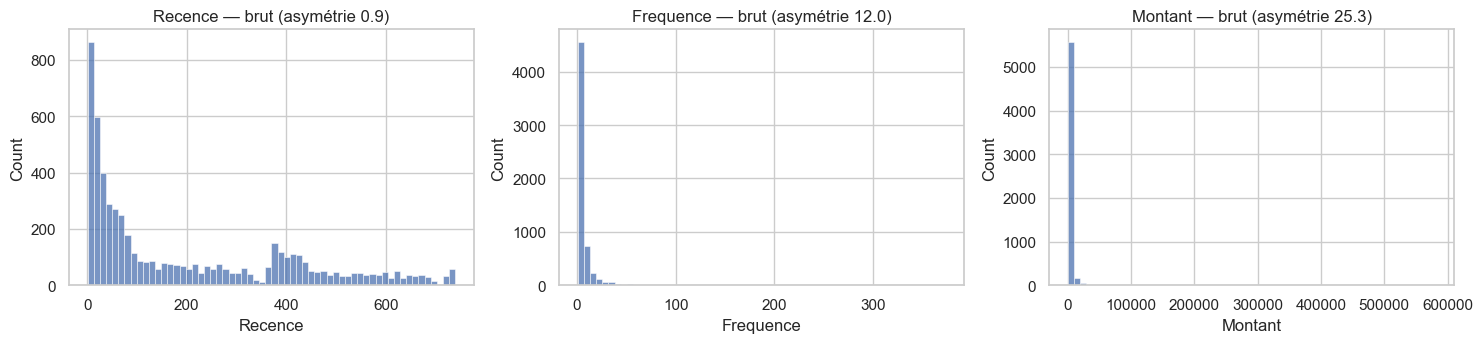

In [15]:
# Une distribution symétrique a une asymétrie proche de 0.
print(rfm[RFM3].skew().round(2))

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
for ax, c in zip(axes, RFM3):
    sns.histplot(rfm[c], bins=60, ax=ax)
    ax.set_title(f"{c} — brut (asymétrie {rfm[c].skew():.1f})")
plt.tight_layout(); plt.savefig(FIG / "L_distributions_brutes.png", dpi=150); plt.show()

## 2.3 Transformation log puis standardisation

           skew_brut  skew_log
Recence         0.89     -0.49
Frequence      12.04      1.00
Montant        25.33      0.27


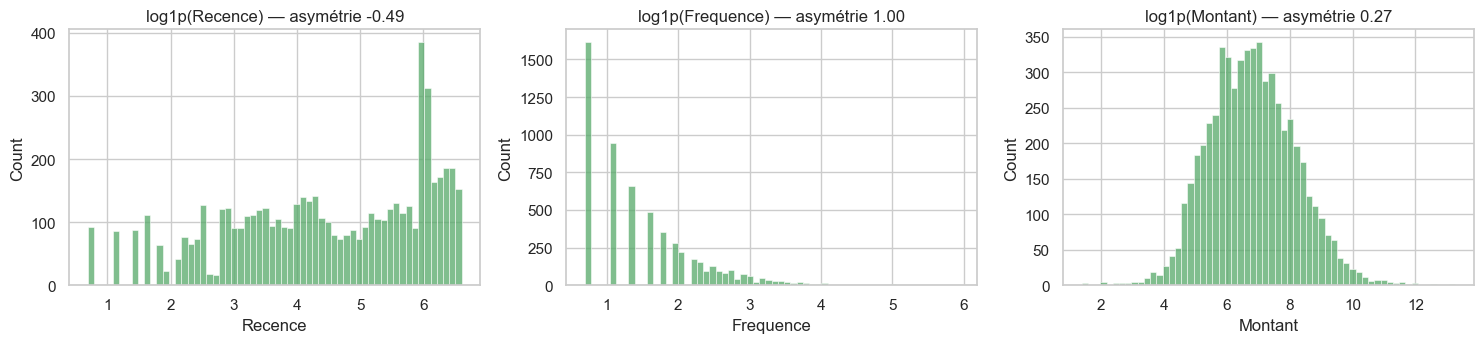

In [16]:
#   1. log1p corrige l'asymétrie (queues très longues à droite)
#   2. StandardScaler égalise le poids des trois variables dans la distance
#      euclidienne pour eviter que le Montant (des milliers) écrase la Récence
#      (des centaines) et la Fréquence (des unités).
rfm_log = rfm[RFM3].apply(np.log1p)
rfm_log.columns = [f"log_{c}" for c in RFM3]

print(pd.DataFrame({"skew_brut": rfm[RFM3].skew().values,
                    "skew_log":  rfm_log.skew().values}, index=RFM3).round(2))

scaler = StandardScaler()
X = scaler.fit_transform(rfm_log)
X_df = pd.DataFrame(X, columns=["R_scaled", "F_scaled", "M_scaled"])

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
for ax, c in zip(axes, RFM3):
    sns.histplot(np.log1p(rfm[c]), bins=60, ax=ax, color="#55A868")
    ax.set_title(f"log1p({c}) — asymétrie {np.log1p(rfm[c]).skew():.2f}")
plt.tight_layout(); plt.savefig(FIG / "L_distributions_log.png", dpi=150); plt.show()

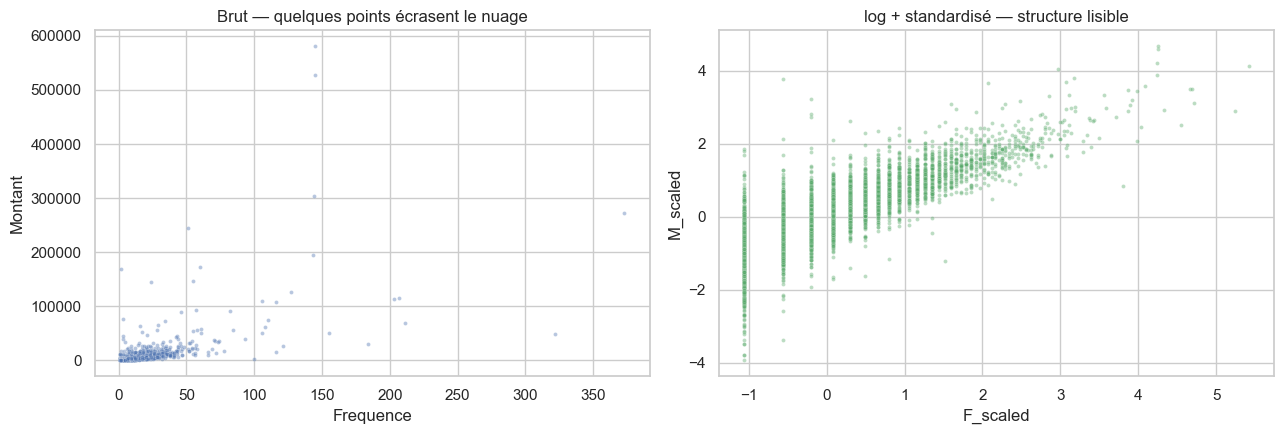

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.scatterplot(x=rfm.Frequence, y=rfm.Montant, s=8, alpha=.4, ax=ax[0])
ax[0].set_title("Brut — quelques points écrasent le nuage")
sns.scatterplot(x=X_df.F_scaled, y=X_df.M_scaled, s=8, alpha=.4, ax=ax[1], color="#55A868")
ax[1].set_title("log + standardisé — structure lisible")
plt.tight_layout(); plt.savefig(FIG / "L_avant_apres.png", dpi=150); plt.show()

## 2.4 Corrélation Fréquence / Montant

Pearson brut :


,Recence,Frequence,Montant
Recence,1.00,-0.26,-0.12
Frequence,-0.26,1.00,0.62
Montant,-0.12,0.62,1.00


Pearson log  :


,log_Recence,log_Frequence,log_Montant
log_Recence,1.00,-0.56,-0.50
log_Frequence,-0.56,1.00,0.85
log_Montant,-0.50,0.85,1.00


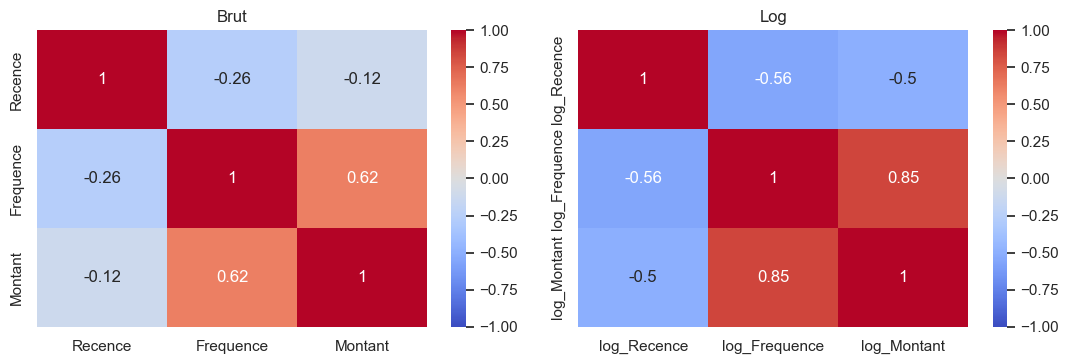

In [18]:

print("Pearson brut :"); display(rfm[RFM3].corr().round(2))
print("Pearson log  :"); display(rfm_log.corr().round(2))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
sns.heatmap(rfm[RFM3].corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=ax[0])
ax[0].set_title("Brut")
sns.heatmap(rfm_log.corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=ax[1])
ax[1].set_title("Log")
plt.tight_layout(); plt.savefig(FIG / "L_correlations.png", dpi=150); plt.show()

- La corrélation brute est trompeuse : les valeurs extrêmes cassent la relation linéaire et la sous-estiment. 
- Après log, la redondance apparaît.

In [19]:
pca_diag = PCA().fit(X)
print("Variance expliquée :", pca_diag.explained_variance_ratio_.round(3))
print("Cumulée            :", pca_diag.explained_variance_ratio_.cumsum().round(3))
display(pd.DataFrame(pca_diag.components_, columns=RFM3,
                     index=["PC1", "PC2", "PC3"]).round(2))

Variance expliquée : [0.763 0.188 0.049]
Cumulée            : [0.763 0.951 1.   ]


,Recence,Frequence,Montant
PC1,-0.50,0.62,0.60
PC2,0.86,0.30,0.41
PC3,0.08,0.73,-0.68


- On conserve R, F, M plutôt que d'appliquer une PCA : les centroïdes doivent
- rester lisibles en jours et en livres pour être défendables devant le marketing.
- La PCA confirme seulement que la structure est bidimensionnelle.

## 2.5 Scores RFM par quintiles (contrôle croisé)

In [39]:

rfm["R_score"] = pd.qcut(rfm.Recence, 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm["F_score"] = pd.qcut(rfm.Frequence.rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["M_score"] = pd.qcut(rfm.Montant, 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["RFM_somme"] = rfm[["R_score", "F_score", "M_score"]].sum(axis=1)

rfm.head()

,CustomerID,Recence,Frequence,Montant,Anciennete,PanierMoyen,R_score,F_score,M_score,RFM_somme,cluster,segment
0,12346,326,3,"77,352.96",647,"25,784.32",2,3,5,10,0,À risque
1,12347,2,8,"4,921.53",404,615.19,5,4,5,14,1,Champions
2,12348,75,5,"1,658.40",438,331.68,3,4,4,11,0,À risque
3,12349,19,3,"3,678.69",589,"1,226.23",5,3,5,13,3,Nouveaux / Prometteurs
4,12350,310,1,294.40,310,294.40,2,1,2,5,2,Perdus / Dormants


## 2.6 Features du jeu net des retours

In [21]:
rfm_net = (pd.read_parquet(PROC / "transactions_clean_net.parquet")
           .groupby("CustomerID")
           .agg(Recence   = ("InvoiceDate", lambda s: (SNAPSHOT - s.max()).days),
                Frequence = ("Invoice", "nunique"),
                Montant   = ("Amount", "sum"))
           .reset_index())

# Un client ayant retourné autant qu'il a acheté a un CA net <= 0 :
# le logarithme est impossible, on l'exclut du jeu net.
exclus = (rfm_net.Montant <= 0).sum()
print(f"Clients à CA net <= 0 : {exclus} ({exclus / len(rfm_net):.2%}) — exclus")
rfm_net = rfm_net[rfm_net.Montant > 0]

X_net = StandardScaler().fit_transform(rfm_net[RFM3].apply(np.log1p))

Clients à CA net <= 0 : 37 (0.63%) — exclus


---
# Partie 3 — Clustering et choix de k

## 3.1 Balayage de k

In [40]:
# n_init=20 : K-means converge vers un optimum local dépendant de son
# initialisation aléatoire. On relance 20 fois et on garde le meilleur.
resultats = []

for k in range(2, 11):
    modele  = KMeans(n_clusters=k, n_init=20, random_state=GRAINE).fit(X)
    tailles = np.bincount(modele.labels_)
    resultats.append({
        "k": k,
        "inertie": modele.inertia_,
        # silhouette estimée sur 5 000 clients
        "silhouette": silhouette_score(X, modele.labels_, sample_size=5000,
                                       random_state=GRAINE),
        "davies_bouldin": davies_bouldin_score(X, modele.labels_),
        "plus_petit_groupe": tailles.min(),
    })

balayage = pd.DataFrame(resultats)
balayage["gain_inertie"] = -balayage.inertie.diff()
balayage.round(3)

,k,inertie,silhouette,davies_bouldin,plus_petit_groupe,gain_inertie
0,2,"8,561.57",0.44,0.87,2312,NaN
1,3,"6,337.39",0.35,1.04,1217,"2,224.18"
2,4,"4,907.57",0.36,0.93,1184,"1,429.83"
3,5,"4,090.03",0.34,0.95,450,817.54
4,6,"3,549.33",0.34,0.96,472,540.70
5,7,"3,181.22",0.30,0.98,332,368.11
6,8,"2,891.99",0.29,0.99,347,289.23
7,9,"2,650.14",0.29,1.01,256,241.86
8,10,"2,459.97",0.29,1.02,225,190.16


## 3.2 Coude et silhouette

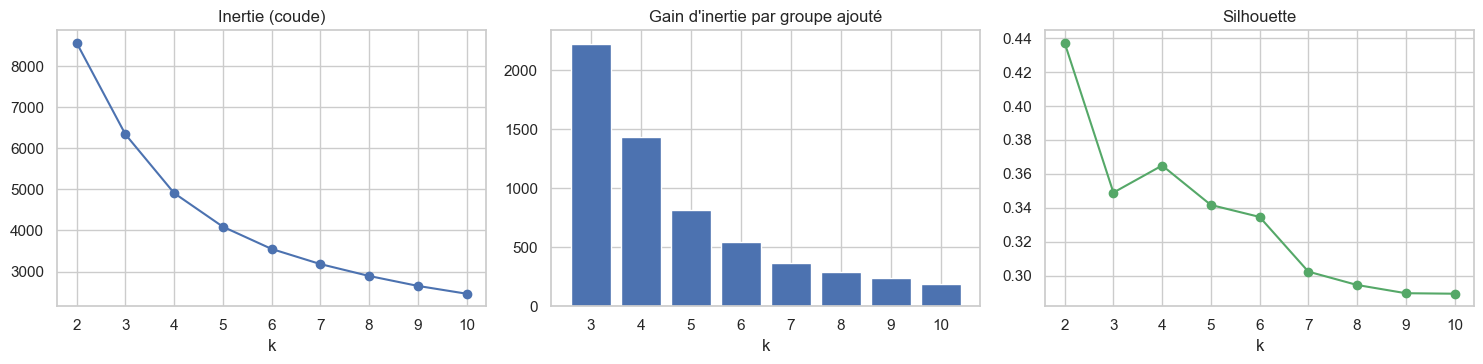

k= 2 | silhouette 0.437 | davies-bouldin 0.874 | plus petit groupe 2,312
k= 3 | silhouette 0.349 | davies-bouldin 1.038 | plus petit groupe 1,217
k= 4 | silhouette 0.365 | davies-bouldin 0.931 | plus petit groupe 1,184
k= 5 | silhouette 0.342 | davies-bouldin 0.950 | plus petit groupe 450
k= 6 | silhouette 0.335 | davies-bouldin 0.962 | plus petit groupe 472
k= 7 | silhouette 0.302 | davies-bouldin 0.982 | plus petit groupe 332
k= 8 | silhouette 0.294 | davies-bouldin 0.992 | plus petit groupe 347
k= 9 | silhouette 0.290 | davies-bouldin 1.015 | plus petit groupe 256
k=10 | silhouette 0.289 | davies-bouldin 1.021 | plus petit groupe 225


In [23]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))

ax[0].plot(balayage.k, balayage.inertie, "o-")
ax[0].set_title("Inertie (coude)"); ax[0].set_xlabel("k")

ax[1].bar(balayage.k[1:], balayage.gain_inertie[1:])
ax[1].set_title("Gain d'inertie par groupe ajouté"); ax[1].set_xlabel("k")

ax[2].plot(balayage.k, balayage.silhouette, "o-", color="#55A868")
ax[2].set_title("Silhouette"); ax[2].set_xlabel("k")

plt.tight_layout(); plt.savefig(FIG / "L_choix_k.png", dpi=150); plt.show()

for _, r in balayage.iterrows():
    print(f"k={int(r.k):2d} | silhouette {r.silhouette:.3f} | "
          f"davies-bouldin {r.davies_bouldin:.3f} | "
          f"plus petit groupe {int(r.plus_petit_groupe):,}")

In [ ]:
- La silhouette est maximale à k=2 : deux segments « actifs / partis » techniquement optimaux mais sans usage marketing. 
- Le coude, lui, fléchit progressivement entre k=3 et k=5 sans angle net. 
- Aucun des deux critères ne suffit seul : ils cadrent une zone, ils ne désignent pas une valeur.

## 3.3 Stabilité par bootstrap

k=3 | ARI moyen 0.955 | minimum 0.915
k=4 | ARI moyen 0.963 | minimum 0.893
k=5 | ARI moyen 0.928 | minimum 0.802
k=6 | ARI moyen 0.890 | minimum 0.749


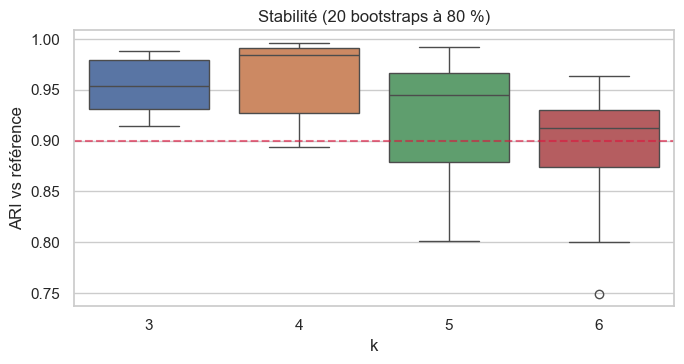

In [24]:
def stabilite(X, k, n_essais=20, part=0.8):
    """Mesure si les segments réapparaissent quand on change l'échantillon.

    On reclusterise sur `part` des clients tirés au hasard, puis on compare
    l'affectation obtenue à celle du modèle de référence par ARI
    (1 = partitions identiques, 0 = accord dû au hasard).
    """
    tirage    = np.random.default_rng(GRAINE)
    reference = KMeans(k, n_init=20, random_state=GRAINE).fit(X)
    scores    = []

    for essai in range(n_essais):
        echantillon = tirage.choice(len(X), int(part * len(X)), replace=False)
        modele      = KMeans(k, n_init=10, random_state=1000 + essai).fit(X[echantillon])
        scores.append(adjusted_rand_score(reference.labels_[echantillon], modele.labels_))

    return np.array(scores)


ari = {}
for k in range(3, 7):
    s = stabilite(X, k)
    ari[k] = s
    print(f"k={k} | ARI moyen {s.mean():.3f} | minimum {s.min():.3f}")

fig, ax = plt.subplots(figsize=(7, 3.8))
sns.boxplot(data=pd.DataFrame(ari), ax=ax)
ax.axhline(0.9, ls="--", c="crimson", alpha=.6)
ax.set_xlabel("k"); ax.set_ylabel("ARI vs référence")
ax.set_title("Stabilité (20 bootstraps à 80 %)")
plt.tight_layout(); plt.savefig(FIG / "L_stabilite.png", dpi=150); plt.show()

## 3.4 Décision

In [25]:

decision = balayage[balayage.k.between(2, 6)][
    ["k", "silhouette", "davies_bouldin", "plus_petit_groupe"]].copy()
decision["ARI"] = decision.k.map({k: v.mean() for k, v in ari.items()})
display(decision.round(3))

K = 4
kmeans = KMeans(n_clusters=K, n_init=20, random_state=GRAINE).fit(X)
rfm["cluster"] = kmeans.labels_

print(rfm.cluster.value_counts().sort_index())

,k,silhouette,davies_bouldin,plus_petit_groupe,ARI
0,2,0.44,0.87,2312,NaN
1,3,0.35,1.04,1217,0.95
2,4,0.36,0.93,1184,0.96
3,5,0.34,0.95,450,0.93
4,6,0.34,0.96,472,0.89


cluster
0    1454
1    1184
2    1968
3    1246
Name: count, dtype: int64


**k = 4** est le point de convergence de quatre indications indépendantes :
   - rebond local de la silhouette (0,365 après la chute de k=2 à k=3)
   - minimum de Davies-Bouldin sur la plage utile
   - aucun segment sous 1 100 clients
   - meilleure stabilité (ARI 0,961)
**Aucune métrique ne le prouve seule.**

## 3.5 Projection en deux dimensions

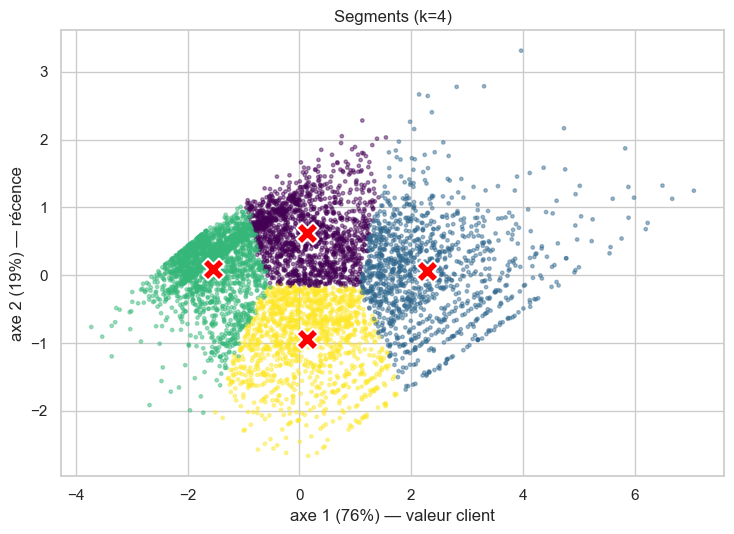

In [26]:
pca  = PCA(n_components=2, random_state=GRAINE)
plan = pca.fit_transform(X)
centres_projetes = pca.transform(kmeans.cluster_centers_)

fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.scatter(plan[:, 0], plan[:, 1], c=kmeans.labels_, s=6, alpha=.45, cmap="viridis")
ax.scatter(centres_projetes[:, 0], centres_projetes[:, 1], c="red", s=250,
           marker="X", edgecolor="white", linewidth=1.5)
ax.set_xlabel(f"axe 1 ({pca.explained_variance_ratio_[0]:.0%}) — valeur client")
ax.set_ylabel(f"axe 2 ({pca.explained_variance_ratio_[1]:.0%}) — récence")
ax.set_title(f"Segments (k={K})")
plt.tight_layout(); plt.savefig(FIG / "L_projection.png", dpi=150); plt.show()



- Frontières franches mais aucun vide entre les groupes : les clients forment un continuum. 
    Le clustering découpe cet espace à des seuils utiles, il ne révèle pas des groupes préexistants.

## 3.6 Effet du traitement des retours

In [27]:
kmeans_net = KMeans(K, n_init=20, random_state=GRAINE).fit(X_net)

comparaison = (
    pd.DataFrame({"CustomerID": rfm.CustomerID.values,     "sans_retours": kmeans.labels_})
    .merge(
    pd.DataFrame({"CustomerID": rfm_net.CustomerID.values, "avec_retours": kmeans_net.labels_}),
    on="CustomerID")
)

score = adjusted_rand_score(comparaison.sans_retours, comparaison.avec_retours)
change = (comparaison.sans_retours != comparaison.avec_retours)

print(f"Clients communs : {len(comparaison):,}")
print(f"ARI             : {score:.3f}")
display(pd.crosstab(comparaison.sans_retours, comparaison.avec_retours))


Clients communs : 5,838
ARI             : 0.876


avec_retours,0,1,2,3
sans_retours,,,,
0,1348,13,77,16
1,65,1089,0,30
2,29,0,1917,10
3,20,12,17,1195


- ARI > 0,85 : la structure des segments ne dépend pas de ce choix de nettoyage. On conserve le jeu principal.

---
# Partie 4 - Caractérisation et recommandations

## 4.1 Profil de chaque cluster

In [28]:
profil = rfm.groupby("cluster").agg(
    effectif     = ("CustomerID", "size"),
    R_moy        = ("Recence", "mean"),
    F_moy        = ("Frequence", "mean"),
    M_moy        = ("Montant", "mean"),
    M_med        = ("Montant", "median"),
    panier_moyen = ("PanierMoyen", "mean"),
    anciennete   = ("Anciennete", "mean"),
)
profil["CA"]          = rfm.groupby("cluster").Montant.sum()
profil["pct_CA"]      = (100 * profil.CA / rfm.Montant.sum()).round(1)
profil["pct_clients"] = (100 * profil.effectif / len(rfm)).round(1)

profil.sort_values("pct_CA", ascending=False).round(1)

,effectif,R_moy,F_moy,M_moy,M_med,panier_moyen,anciennete,CA,pct_CA,pct_clients
cluster,,,,,,,,,,
1,1184,27.70,19.20,"10,580.70","4,905.00",556.00,614.70,"12,527,597.40",73.40,20.20
0,1454,227.70,5.10,"1,973.60","1,453.30",488.70,573.90,"2,869,553.60",16.80,24.80
3,1246,28.20,3.00,841.40,720.40,313.20,277.60,"1,048,418.90",6.10,21.30
2,1968,392.50,1.40,316.90,275.60,249.20,439.80,"623,743.80",3.70,33.60


## 4.2 Nommage des segments

In [29]:
def nommer(profil):
    """Nomme les clusters par leur position relative, jamais par leur numéro.

    Les numéros attribués par K-means sont arbitraires et changent avec la
    graine. Un seuil fixe (ex. la médiane) serait fragile : un cluster situé
    pile dessus basculerait au hasard des arrondis.
    """
    restants, noms = list(profil.index), {}

    c = profil.loc[restants].R_moy.idxmax()      # parti depuis le plus longtemps
    noms[c] = "Perdus / Dormants"; restants.remove(c)

    c = profil.loc[restants].M_moy.idxmax()      # dépense le plus
    noms[c] = "Champions"; restants.remove(c)

    c = profil.loc[restants].R_moy.idxmax()      # le plus ancien des deux restants
    noms[c] = "À risque"; restants.remove(c)

    noms[restants[0]] = "Nouveaux / Prometteurs"
    return noms


NOMS = nommer(profil)
rfm["segment"]    = rfm.cluster.map(NOMS)
profil["segment"] = profil.index.map(NOMS)

assert profil.segment.nunique() == len(profil), "Deux clusters portent le même nom"
for c, n in sorted(NOMS.items()):
    print(f"cluster {c} → {n}")

cluster 0 → À risque
cluster 1 → Champions
cluster 2 → Perdus / Dormants
cluster 3 → Nouveaux / Prometteurs


## 4.3 Pays et produits dominants

In [30]:
tx = df.merge(rfm[["CustomerID", "cluster", "segment"]], on="CustomerID")

def enrichir(g):
    ca = g.Amount.sum()
    pays = g.groupby("Country").Amount.sum().nlargest(2)
    prod = g.groupby("Description").Amount.sum().nlargest(3)
    return {
        "top_pays":     ", ".join(f"{p} ({100 * v / ca:.0f} %)" for p, v in pays.items()),
        "top_produits": " · ".join(str(p).title()[:28] for p in prod.index),
        # Nombre de références distinctes : révèle le profil grossiste.
        "refs_par_client": g.groupby("CustomerID").StockCode.nunique().mean().round(1),
    }

enrichi = pd.DataFrame({c: enrichir(g) for c, g in tx.groupby("cluster")}).T
enrichi.index.name = "cluster"
enrichi

,top_pays,top_produits,refs_par_client
cluster,,,
0,"United Kingdom (87 %), Germany (2 %)",Medium Ceramic Top Storage J · White Hanging H...,81.20
1,"United Kingdom (82 %), EIRE (5 %)",Regency Cakestand 3 Tier · White Hanging Heart...,208.40
2,"United Kingdom (90 %), France (1 %)",White Hanging Heart T-Light · Regency Cakesta...,22.80
3,"United Kingdom (89 %), Germany (2 %)",Regency Cakestand 3 Tier · White Hanging Heart...,57.20


## 4.4 Tableau de synthèse

In [31]:
synthese = pd.DataFrame({
    "Segment":          profil.segment,
    "Effectif":         profil.effectif,
    "% clients":        profil.pct_clients,
    "% CA":             profil.pct_CA,
    "Récence moy. (j)": profil.R_moy.round(0),
    "Fréquence moy.":   profil.F_moy.round(1),
    "Montant moy. (£)": profil.M_moy.round(0),
    "Panier moyen (£)": profil.panier_moyen.round(0),
    "Réfs / client":    enrichi.refs_par_client,
    "Top pays":         enrichi.top_pays,
    "Top produits":     enrichi.top_produits,
}).sort_values("% CA", ascending=False).reset_index(drop=True)

synthese.to_csv(PROC / "tableau_synthese.csv", index=False)
synthese

,Segment,Effectif,% clients,% CA,Récence moy. (j),Fréquence moy.,Montant moy. (£),Panier moyen (£),Réfs / client,Top pays,Top produits
0,Champions,1184,20.20,73.40,28.00,19.20,"10,581.00",556.00,208.40,"United Kingdom (82 %), EIRE (5 %)",Regency Cakestand 3 Tier · White Hanging Heart...
1,À risque,1454,24.80,16.80,228.00,5.10,"1,974.00",489.00,81.20,"United Kingdom (87 %), Germany (2 %)",Medium Ceramic Top Storage J · White Hanging H...
2,Nouveaux / Prometteurs,1246,21.30,6.10,28.00,3.00,841.00,313.00,57.20,"United Kingdom (89 %), Germany (2 %)",Regency Cakestand 3 Tier · White Hanging Heart...
3,Perdus / Dormants,1968,33.60,3.70,393.00,1.40,317.00,249.00,22.80,"United Kingdom (90 %), France (1 %)",White Hanging Heart T-Light · Regency Cakesta...


## 4.5 Visualisations

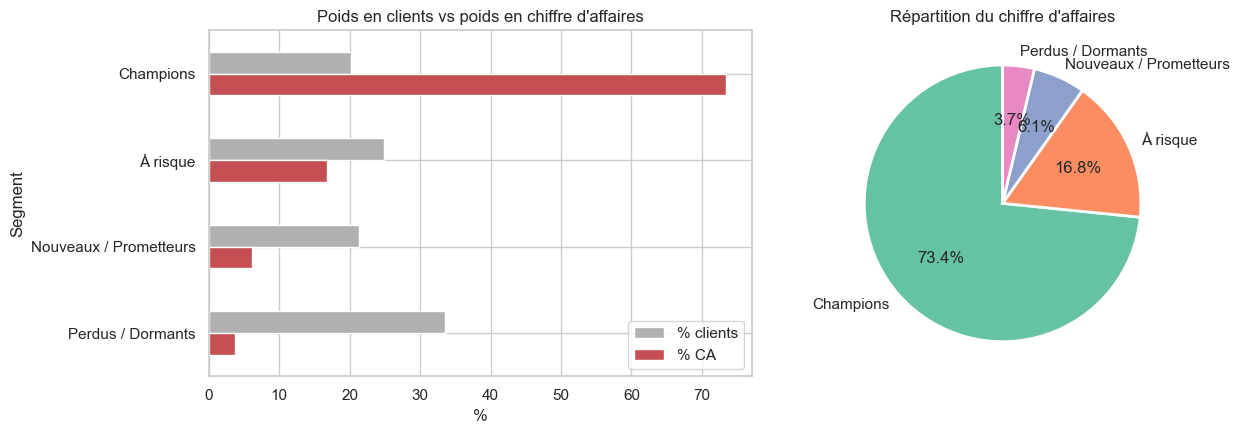

In [32]:
ordre = synthese.Segment.tolist()
palette = dict(zip(ordre, sns.color_palette("Set2", len(ordre))))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
synthese.set_index("Segment")[["% clients", "% CA"]].plot(
    kind="barh", ax=ax[0], color=["#B0B0B0", "#C44E52"])
ax[0].set_title("Poids en clients vs poids en chiffre d'affaires")
ax[0].invert_yaxis(); ax[0].set_xlabel("%")

ax[1].pie(synthese["% CA"], labels=synthese.Segment, autopct="%1.1f%%",
          colors=[palette[s] for s in ordre], startangle=90,
          wedgeprops={"edgecolor": "white", "linewidth": 2})
ax[1].set_title("Répartition du chiffre d'affaires")
plt.tight_layout(); plt.savefig(FIG / "L_poids_segments.png", dpi=150); plt.show()

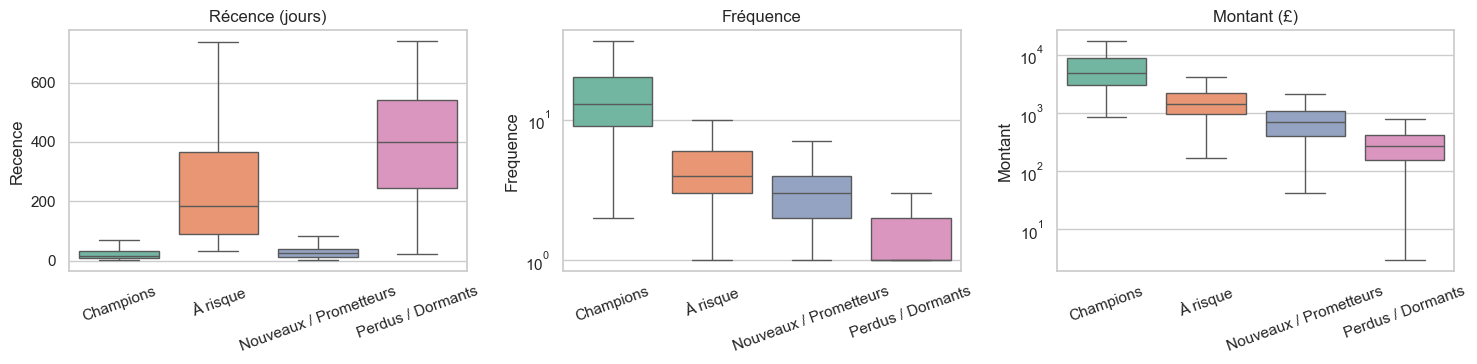

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, (col, titre) in zip(axes, [("Recence", "Récence (jours)"),
                                   ("Frequence", "Fréquence"),
                                   ("Montant", "Montant (£)")]):
    sns.boxplot(data=rfm, x="segment", y=col, order=ordre, hue="segment",
                palette=palette, legend=False, ax=ax, showfliers=False)
    ax.set_title(titre); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=20)
    if col != "Recence":
        ax.set_yscale("log")     # échelle log : sinon les Champions écrasent tout
plt.tight_layout(); plt.savefig(FIG / "L_distributions_segments.png", dpi=150); plt.show()

## 4.6 Contrôle croisé avec la grille RFM

In [34]:
# Si les clusters recoupent la grille par quintiles, les deux approches se
# valident mutuellement. Les scores doivent décroître dans le même ordre que
# la part de chiffre d'affaires.
controle = rfm.groupby("segment")[["R_score", "F_score", "M_score", "RFM_somme"]].mean()
display(controle.sort_values("RFM_somme", ascending=False).round(2))


,R_score,F_score,M_score,RFM_somme
segment,,,,
Champions,4.45,4.84,4.78,14.07
À risque,2.45,3.59,3.72,9.75
Nouveaux / Prometteurs,4.32,2.72,2.70,9.74
Perdus / Dormants,1.73,1.63,1.59,4.95


- « À risque » et « Nouveaux » obtiennent un score agrégé proche alors que leurs profils sont opposés. 
- Une grille par score les confondrait 

## 4.7 Recommandations

In [35]:
recommandations = pd.DataFrame([
    {"Segment": "Champions",
     "Constat": "20 % des clients, 73 % du CA, dernier achat il y a moins d'un mois",
     "Action": "Fidélisation premium : accès anticipé, contact commercial dédié, conditions de gros",
     "Indicateur": "rétention à 12 mois", "Priorité": 1},
    {"Segment": "À risque",
     "Constat": "Bon historique mais plus d'achat depuis environ 7 mois",
     "Action": "Réactivation ciblée sur leurs références habituelles, offre limitée dans le temps",
     "Indicateur": "réachat à 60 jours", "Priorité": 2},
    {"Segment": "Nouveaux / Prometteurs",
     "Constat": "Achat récent mais 3 commandes en moyenne, panier modeste",
     "Action": "Onboarding : recommandations croisées, remise sur la deuxième commande",
     "Indicateur": "passage à 3 commandes ou plus", "Priorité": 2},
    {"Segment": "Perdus / Dormants",
     "Constat": "Une seule commande, il y a plus d'un an, faible montant",
     "Action": "Win-back à coût maîtrisé, sans remise agressive ; sortie de la base si sans réponse",
     "Indicateur": "coût par client réactivé", "Priorité": 3},
])

recommandations.to_csv(PROC / "recommandations.csv", index=False)
recommandations

,Segment,Constat,Action,Indicateur,Priorité
0,Champions,"20 % des clients, 73 % du CA, dernier achat il...","Fidélisation premium : accès anticipé, contact...",rétention à 12 mois,1
1,À risque,Bon historique mais plus d'achat depuis enviro...,Réactivation ciblée sur leurs références habit...,réachat à 60 jours,2
2,Nouveaux / Prometteurs,"Achat récent mais 3 commandes en moyenne, pani...","Onboarding : recommandations croisées, remise ...",passage à 3 commandes ou plus,2
3,Perdus / Dormants,"Une seule commande, il y a plus d'un an, faibl...","Win-back à coût maîtrisé, sans remise agressiv...",coût par client réactivé,3


## 4.8 Sauvegarde

In [36]:
rfm.to_parquet(PROC / "rfm_segments.parquet", index=False)
joblib.dump({"kmeans": kmeans, "scaler": scaler, "k": K,
             "snapshot": SNAPSHOT, "cols": RFM3}, PROC / "modele.joblib")

print("Sorties :")
for f in ["journal_nettoyage.csv", "tableau_synthese.csv", "recommandations.csv",
          "rfm_segments.parquet", "modele.joblib"]:
    print("  ", f)

Sorties :
   journal_nettoyage.csv
   tableau_synthese.csv
   recommandations.csv
   rfm_segments.parquet
   modele.joblib


---
## Synthèse

| | Résultat |
|---|---|
| Transactions nettoyées | 776 582 sur 1 067 371 (72,8 %) |
| Clients segmentés | 5 852 |
| Nombre de segments | 4 (silhouette 0,365 · ARI bootstrap 0,961) |
| Concentration | 20 % des clients = 73 % du chiffre d'affaires |
| Effet des retours | ARI 0,876 — structure inchangée |

La discussion critique, les limites méthodologiques et les enjeux éthiques
sont développés dans le rapport joint.